# Sumativa 3 - Proyecto Final Integrado

## MCDI501 - Estadística Computacional para la Toma de Decisiones

### Magíster en Ciencia de Datos e Inteligencia Artificial

**Universidad Andrés Bello**

---

## Integrantes

- Pablo Rodríguez
- Luiskar Espinoza

---

## Objetivo

Desarrollar el proyecto final integrado del curso, aplicando modelos de regresión lineal y regresión logística para apoyar la toma de decisiones sobre el riesgo de enfermedad coronaria a diez años, integrando de manera trazable los resultados obtenidos durante las Sumativas 1 y 2 mediante análisis exploratorio, inferencia estadística, técnicas de remuestreo y simulación.

---

**Dataset utilizado**

Framingham Heart Study

# Índice

1. Importación de librerías

2. Configuración del proyecto

3. Carga del conjunto de datos

4. Integración de resultados de S1 y S2

## Parte 1 - Manejo inteligente de datos faltantes

5. Resultados provenientes de S1

6. Imputación simple

7. Imputación mediante regresión lineal múltiple

8. Comparación de estrategias de imputación

## Parte 2 - Modelamiento predictivo

9. Preparación del conjunto de datos

10. Modelo 1 (basado en S1 y S2)

11. Modelo 2 (selección Stepwise)

12. Modelo 3 (criterios AIC/BIC)

## Parte 3 - Bootstrap del modelo

13. Estabilidad de coeficientes

14. Intervalos de confianza Bootstrap

## Parte 4 - Diagnóstico del modelo

15. Multicolinealidad

16. Observaciones influyentes

17. Linealidad del logit

18. Residuos

## Parte 5 - Comparación de modelos

19. Comparación entre estrategias de imputación

20. Selección del modelo final

## Parte 6 - Exportación

21. Exportación de resultados

22. Síntesis final

# 1. Importación de librerías

In [5]:
# ==========================================
# Librerías principales
# ==========================================

from pathlib import Path

import warnings
warnings.filterwarnings("ignore")

# ==========================================
# Manejo de datos
# ==========================================

import numpy as np
import pandas as pd

# ==========================================
# Visualización
# ==========================================

import matplotlib.pyplot as plt

# ==========================================
# Machine Learning
# ==========================================

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import (
    LogisticRegression,
    LinearRegression
)

from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.metrics import classification_report
# ==========================================
# Statsmodels
# ==========================================

import statsmodels.api as sm

from statsmodels.stats.outliers_influence import (
    variance_inflation_factor
)

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


# 2. Configuración del proyecto

## Configuración de directorios

In [6]:
# ==========================================
# Directorios del proyecto
# ==========================================

PROJECT_ROOT = Path.cwd().parents[2]

DATA_PATH = (
    PROJECT_ROOT /
    "datos" /
    "original" /
    "framingham.csv"
)

FIGURES_DIR = (
    PROJECT_ROOT /
    "F4" /
    "Sumativa3" /
    "figures"
)

RESULTS_DIR = (
    PROJECT_ROOT /
    "F4" /
    "Sumativa3" /
    "results"
)

REPORT_DIR = (
    PROJECT_ROOT /
    "F4" /
    "Sumativa3" /
    "report"
)

PRESENTATION_DIR = (
    PROJECT_ROOT /
    "F4" /
    "Sumativa3" /
    "presentation"
)

# Crear directorios si no existen
FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

PRESENTATION_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Directorios configurados correctamente.")

Directorios configurados correctamente.


## Configuración general

In [7]:
# ==========================================
# Parámetros generales
# ==========================================

SEED = 42

np.random.seed(SEED)

TEST_SIZE = 0.30

ALPHA = 0.05

N_BOOTSTRAP = 10000

print("Semilla:", SEED)

print("Nivel de significancia:", ALPHA)

print("Bootstrap:", N_BOOTSTRAP)

Semilla: 42
Nivel de significancia: 0.05
Bootstrap: 10000


# 3. Carga del conjunto de datos

## Carga y verificación del conjunto de datos

In [8]:
# ==========================================
# Carga del dataset
# ==========================================

df = pd.read_csv(DATA_PATH)

print("=" * 60)
print("Conjunto de datos cargado correctamente")
print("=" * 60)

print(f"Observaciones : {df.shape[0]}")

print(f"Variables     : {df.shape[1]}")

display(df.head())

Conjunto de datos cargado correctamente
Observaciones : 4238
Variables     : 16


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


# 4. Integración de resultados de S1 y S2

## Integración de resultados previos

La presente evaluación constituye la etapa final del proyecto, por lo que todas las decisiones metodológicas se fundamentan en los resultados obtenidos durante las evaluaciones anteriores.

**Resultados incorporados desde la Sumativa 1**

- Identificación de variables con valores faltantes.
- Caracterización del patrón de datos faltantes.
- Identificación de valores atípicos.
- Correlaciones entre variables clínicas.
- Pruebas de hipótesis sobre variables relevantes.
- Estadística descriptiva e inferencial.

**Resultados incorporados desde la Sumativa 2**

- Validación bootstrap de parámetros.
- Validación mediante test de permutación.
- Estabilidad de correlaciones.
- Simulación Monte Carlo.
- Análisis de robustez.
- Parámetros estadísticamente estables.

Estos antecedentes constituyen la base para la selección de variables, el tratamiento de datos faltantes y la construcción de los modelos predictivos desarrollados en esta evaluación.

# Parte 1 - Manejo inteligente de datos faltantes

## 5. Resultados provenientes de la Sumativa 1

Durante la Sumativa 1 se identificó la presencia de valores faltantes en diversas variables clínicas del conjunto de datos Framingham Heart Study.

En lugar de repetir dicho análisis, en esta etapa se utilizan esos resultados como insumo para definir y comparar distintas estrategias de tratamiento de datos faltantes, tal como establece la metodología del proyecto.

In [9]:
# ==========================================
# Resumen de valores faltantes (Resultados S1)
# ==========================================

faltantes = pd.DataFrame({

    "Valores faltantes": df.isnull().sum(),

    "Porcentaje (%)": (
        df.isnull().mean()*100
    ).round(2)

})

faltantes = faltantes[
    faltantes["Valores faltantes"] > 0
]

print("=" * 60)
print("Resumen de valores faltantes (S1)")
print("=" * 60)

display(faltantes)

Resumen de valores faltantes (S1)


,Valores faltantes,Porcentaje (%)
education,105,2.48
cigsPerDay,29,0.68
BPMeds,53,1.25
totChol,50,1.18
BMI,19,0.45
heartRate,1,0.02
glucose,388,9.16


## Variables con datos faltantes

La siguiente tabla resume las variables que presentan valores faltantes y constituye el punto de partida para comparar las tres estrategias de tratamiento consideradas en esta evaluación:

- Eliminación de observaciones (`dropna`).
- Imputación simple.
- Imputación mediante regresión lineal múltiple.

In [10]:
# ==========================================
# Variables que serán imputadas
# ==========================================

variables_faltantes = list(faltantes.index)

print("Variables con datos faltantes:\n")

for variable in variables_faltantes:
    print(f"• {variable}")

Variables con datos faltantes:

• education
• cigsPerDay
• BPMeds
• totChol
• BMI
• heartRate
• glucose


## Orden del tratamiento de datos faltantes

De acuerdo con la orientación metodológica entregada para esta evaluación, las tres estrategias de tratamiento de datos faltantes se aplican sobre la base completa antes de realizar la separación entre entrenamiento y prueba.

Posteriormente, cada conjunto resultante se divide utilizando la misma semilla y la misma asignación general de registros, con el propósito de mantener la reproducibilidad y facilitar la comparación entre estrategias.

In [11]:
# ==========================================
# Estrategias 1 y 2 sobre la base completa
# ==========================================

TARGET = "TenYearCHD"

# ------------------------------------------
# Estrategia 1: eliminación
# ------------------------------------------

df_dropna = df.dropna().copy()

# ------------------------------------------
# Estrategia 2: imputación simple
# ------------------------------------------

df_simple = df.copy()

columnas_moda = [
    columna
    for columna in ["education", "BPMeds"]
    if columna in df.columns
    and df[columna].isna().any()
]

columnas_mediana = [
    columna
    for columna in df.columns
    if columna != TARGET
    and columna not in columnas_moda
    and df[columna].isna().any()
]

imputador_moda = SimpleImputer(
    strategy="most_frequent"
)

imputador_mediana = SimpleImputer(
    strategy="median"
)

df_simple[columnas_moda] = (
    imputador_moda.fit_transform(
        df[columnas_moda]
    )
)

df_simple[columnas_mediana] = (
    imputador_mediana.fit_transform(
        df[columnas_mediana]
    )
)

print("=" * 60)
print("ESTRATEGIAS SOBRE LA BASE COMPLETA")
print("=" * 60)

print("Base original:", df.shape)
print("Eliminación:", df_dropna.shape)
print("Imputación simple:", df_simple.shape)

print("\nVariables imputadas con moda:")
print(columnas_moda)

print("\nVariables imputadas con mediana:")
print(columnas_mediana)

assert df_dropna.isna().sum().sum() == 0
assert df_simple.isna().sum().sum() == 0

print("\nValidación correcta: no existen valores faltantes.")

ESTRATEGIAS SOBRE LA BASE COMPLETA
Base original: (4238, 16)
Eliminación: (3656, 16)
Imputación simple: (4238, 16)

Variables imputadas con moda:
['education', 'BPMeds']

Variables imputadas con mediana:
['cigsPerDay', 'totChol', 'BMI', 'heartRate', 'glucose']

Validación correcta: no existen valores faltantes.


## Estrategia 3: imputación por regresión de `glucose`

`glucose` es la variable con mayor cantidad de datos faltantes: 388 registros, equivalentes al 9,16 % de la base analizada.

Para esta estrategia, las demás variables incompletas se completan mediante métodos simples y `glucose` se imputa mediante regresión lineal múltiple. Se utilizan cinco predictores derivados del análisis previo: `diabetes`, `age`, `BMI`, `sysBP` y `totChol`.

El desempeño del modelo de imputación se evalúa mediante R², RMSE y MAE. Un R² bajo no se oculta, ya que refleja la débil relación lineal de `glucose` con los predictores disponibles.

In [28]:
# ==========================================
# Preparación de la imputación por regresión
# centrada en glucose
# ==========================================

df_regresion = df.copy()

# Variables ordinales o binarias
columnas_moda_regresion = [
    columna
    for columna in ["education", "BPMeds"]
    if columna in df_regresion.columns
    and df_regresion[columna].isna().any()
]

for columna in columnas_moda_regresion:

    valor_moda = (
        df_regresion[columna]
        .mode(dropna=True)
        .iloc[0]
    )

    df_regresion[columna] = (
        df_regresion[columna]
        .fillna(valor_moda)
    )

# Variables numéricas distintas de glucose
columnas_mediana_regresion = [
    columna
    for columna in variables_faltantes
    if columna not in (
        columnas_moda_regresion
        + ["glucose"]
    )
]

for columna in columnas_mediana_regresion:

    valor_mediana = (
        df_regresion[columna]
        .median()
    )

    df_regresion[columna] = (
        df_regresion[columna]
        .fillna(valor_mediana)
    )

predictores_glucose = [
    "diabetes",
    "age",
    "BMI",
    "sysBP",
    "totChol"
]

mascara_glucose_observada = (
    df_regresion["glucose"].notna()
)

datos_glucose_observados = (
    df_regresion.loc[
        mascara_glucose_observada,
        predictores_glucose + ["glucose"]
    ]
    .copy()
)

X_glucose = (
    datos_glucose_observados[
        predictores_glucose
    ]
)

y_glucose = (
    datos_glucose_observados["glucose"]
)

print("Registros observados de glucose:", len(y_glucose))
print(
    "Valores de glucose por imputar:",
    int(df_regresion["glucose"].isna().sum())
)

Registros observados de glucose: 3850
Valores de glucose por imputar: 388


In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

print("SEED:", SEED)
print("X_glucose:", X_glucose.shape)
print("y_glucose:", y_glucose.shape)

print("\nFaltantes en X_glucose:")
print(X_glucose.isna().sum())

print("\nFaltantes en y_glucose:")
print(y_glucose.isna().sum())

SEED: 42
X_glucose: (3850, 5)
y_glucose: (3850,)

Faltantes en X_glucose:
diabetes    0
age         0
BMI         0
sysBP       0
totChol     0
dtype: int64

Faltantes en y_glucose:
0


In [26]:
# ==========================================
# Evaluación del modelo de imputación
# ==========================================

(
    X_glucose_ajuste,
    X_glucose_validacion,
    y_glucose_ajuste,
    y_glucose_validacion
) = train_test_split(
    X_glucose,
    y_glucose,
    test_size=0.20,
    random_state=SEED
)

modelo_glucose_evaluacion = LinearRegression()

modelo_glucose_evaluacion.fit(
    X_glucose_ajuste,
    y_glucose_ajuste
)

pred_glucose_validacion = (
    modelo_glucose_evaluacion.predict(
        X_glucose_validacion
    )
)

r2_glucose = r2_score(
    y_glucose_validacion,
    pred_glucose_validacion
)

rmse_glucose = np.sqrt(
    mean_squared_error(
        y_glucose_validacion,
        pred_glucose_validacion
    )
)

mae_glucose = mean_absolute_error(
    y_glucose_validacion,
    pred_glucose_validacion
)

evaluacion_imputacion_glucose = pd.DataFrame({
    "Variable": ["glucose"],
    "Predictores": [
        ", ".join(predictores_glucose)
    ],
    "R2 validación": [r2_glucose],
    "RMSE validación": [rmse_glucose],
    "MAE validación": [mae_glucose],
    "Cantidad a imputar": [
        int(
            df_regresion[
                "glucose"
            ].isna().sum()
        )
    ]
})

display(
    evaluacion_imputacion_glucose.round(4)
)

,Variable,Predictores,R2 validación,RMSE validación,MAE validación,Cantidad a imputar
0,glucose,"diabetes, age, BMI, sysBP, totChol",0.2624,20.3004,11.6819,0


In [29]:
# ==========================================
# Ajuste final e imputación de glucose
# ==========================================

modelo_glucose_final = LinearRegression()

modelo_glucose_final.fit(
    X_glucose,
    y_glucose
)

mascara_glucose_faltante = (
    df_regresion["glucose"].isna()
)

valores_glucose_imputados = (
    modelo_glucose_final.predict(
        df_regresion.loc[
            mascara_glucose_faltante,
            predictores_glucose
        ]
    )
)

df_regresion.loc[
    mascara_glucose_faltante,
    "glucose"
] = valores_glucose_imputados

assert df_regresion.isna().sum().sum() == 0

print("=" * 60)
print("IMPUTACIÓN POR REGRESIÓN FINALIZADA")
print("=" * 60)

print(
    "Valores de glucose imputados:",
    int(mascara_glucose_faltante.sum())
)

print(
    "Mínimo imputado:",
    round(
        valores_glucose_imputados.min(),
        3
    )
)

print(
    "Máximo imputado:",
    round(
        valores_glucose_imputados.max(),
        3
    )
)

print("\nFaltantes restantes:")
print(df_regresion.isna().sum().sum())

IMPUTACIÓN POR REGRESIÓN FINALIZADA
Valores de glucose imputados: 388
Mínimo imputado: 75.792
Máximo imputado: 172.504

Faltantes restantes:
0


In [17]:
# ==========================================
# Variabilidad de glucose según estrategia
# ==========================================

comparacion_glucose = pd.DataFrame([
    {
        "Estrategia": "Datos observados",
        "N": df["glucose"].notna().sum(),
        "Media": df["glucose"].dropna().mean(),
        "Mediana": df["glucose"].dropna().median(),
        "Varianza": df["glucose"].dropna().var(),
        "Desviación estándar": (
            df["glucose"].dropna().std()
        )
    },
    {
        "Estrategia": "Imputación simple",
        "N": len(df_simple),
        "Media": df_simple["glucose"].mean(),
        "Mediana": df_simple["glucose"].median(),
        "Varianza": df_simple["glucose"].var(),
        "Desviación estándar": (
            df_simple["glucose"].std()
        )
    },
    {
        "Estrategia": "Imputación regresión",
        "N": len(df_regresion),
        "Media": df_regresion["glucose"].mean(),
        "Mediana": df_regresion["glucose"].median(),
        "Varianza": df_regresion["glucose"].var(),
        "Desviación estándar": (
            df_regresion["glucose"].std()
        )
    }
])

display(
    comparacion_glucose.round(3)
)

,Estrategia,N,Media,Mediana,Varianza,Desviación estándar
0,Datos observados,3850,81.967,78.000,574.082,23.960
1,Imputación simple,4238,81.604,78.000,522.819,22.865
2,Imputación regresión,4238,81.817,78.155,529.638,23.014


## Separación en entrenamiento y prueba

Una vez generadas las tres bases completas, se realiza la división en entrenamiento y prueba. La misma asignación general de índices se utiliza para la imputación simple y la imputación por regresión. En la estrategia de eliminación se conservan únicamente los índices que permanecen después de retirar registros incompletos.

In [18]:
# ==========================================
# Separación posterior al tratamiento
# ==========================================

train_indices, test_indices = train_test_split(
    df.index,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=df[TARGET]
)

def separar_dataset_por_indices(
    dataset,
    indices_train,
    indices_test
):
    indices_train_disponibles = (
        indices_train[
            indices_train.isin(
                dataset.index
            )
        ]
    )

    indices_test_disponibles = (
        indices_test[
            indices_test.isin(
                dataset.index
            )
        ]
    )

    train = (
        dataset.loc[
            indices_train_disponibles
        ]
        .copy()
    )

    test = (
        dataset.loc[
            indices_test_disponibles
        ]
        .copy()
    )

    return train, test


df_train_dropna, df_test_dropna = (
    separar_dataset_por_indices(
        df_dropna,
        train_indices,
        test_indices
    )
)

df_train_simple, df_test_simple = (
    separar_dataset_por_indices(
        df_simple,
        train_indices,
        test_indices
    )
)

df_train_regresion, df_test_regresion = (
    separar_dataset_por_indices(
        df_regresion,
        train_indices,
        test_indices
    )
)

resumen_particiones = pd.DataFrame([
    {
        "Estrategia": "Eliminación",
        "Entrenamiento": len(df_train_dropna),
        "Prueba": len(df_test_dropna),
        "Prevalencia entrenamiento": (
            df_train_dropna[TARGET].mean()
        ),
        "Prevalencia prueba": (
            df_test_dropna[TARGET].mean()
        )
    },
    {
        "Estrategia": "Imputación simple",
        "Entrenamiento": len(df_train_simple),
        "Prueba": len(df_test_simple),
        "Prevalencia entrenamiento": (
            df_train_simple[TARGET].mean()
        ),
        "Prevalencia prueba": (
            df_test_simple[TARGET].mean()
        )
    },
    {
        "Estrategia": "Imputación regresión",
        "Entrenamiento": len(df_train_regresion),
        "Prueba": len(df_test_regresion),
        "Prevalencia entrenamiento": (
            df_train_regresion[TARGET].mean()
        ),
        "Prevalencia prueba": (
            df_test_regresion[TARGET].mean()
        )
    }
])

display(
    resumen_particiones.round(4)
)

assert df_train_simple.isna().sum().sum() == 0
assert df_test_simple.isna().sum().sum() == 0
assert df_train_regresion.isna().sum().sum() == 0
assert df_test_regresion.isna().sum().sum() == 0

print("Separación realizada correctamente.")

,Estrategia,Entrenamiento,Prueba,Prevalencia entrenamiento,Prevalencia prueba
0,Eliminación,2539,1117,0.1516,0.1540
1,Imputación simple,2966,1272,0.1521,0.1517
2,Imputación regresión,2966,1272,0.1521,0.1517


Separación realizada correctamente.


# Parte 2 - Clasificación mediante regresión logística

## Preparación del modelamiento

La prevalencia de `TenYearCHD` en el conjunto de entrenamiento se utiliza para caracterizar el desbalance de clases. Debido a que la clase positiva representa aproximadamente el 15,2 %, los modelos se ajustan utilizando ponderación inversa a la frecuencia de cada clase.

Las presiones sistólica y diastólica se incorporan inicialmente como variables candidatas. Su permanencia se decide mediante el factor de inflación de varianza y no únicamente a partir de su correlación bivariada.

In [19]:
# ==========================================
# Prevalencia y pesos balanceados
# ==========================================

y_train = (
    df_train_regresion[TARGET]
    .copy()
)

y_test = (
    df_test_regresion[TARGET]
    .copy()
)

prevalencia_chd_train = (
    y_train.mean()
)

conteos_clase = (
    y_train.value_counts()
    .sort_index()
)

mapa_pesos_clase = {
    clase: (
        len(y_train)
        /
        (
            len(conteos_clase)
            * cantidad
        )
    )
    for clase, cantidad
    in conteos_clase.items()
}

pesos_train = (
    y_train
    .map(mapa_pesos_clase)
    .astype(float)
)

print("=" * 60)
print("DESBALANCE DE CLASES")
print("=" * 60)

print(
    "Prevalencia TenYearCHD en entrenamiento:",
    round(
        prevalencia_chd_train * 100,
        2
    ),
    "%"
)

print("\nConteos:")
print(conteos_clase)

print("\nPesos de clase:")
print(mapa_pesos_clase)

DESBALANCE DE CLASES
Prevalencia TenYearCHD en entrenamiento: 15.21 %

Conteos:
TenYearCHD
0    2515
1     451
Name: count, dtype: int64

Pesos de clase:
{0: 0.589662027833002, 1: 3.2882483370288247}


In [20]:
# ==========================================
# Variables candidatas
# ==========================================

variables_candidatas = [
    "age",
    "sysBP",
    "diaBP",
    "totChol",
    "BMI",
    "glucose",
    "heartRate",
    "male",
    "currentSmoker"
]

variables_continuas = [
    "age",
    "sysBP",
    "diaBP",
    "totChol",
    "BMI",
    "glucose",
    "heartRate"
]

variables_modelo1_inicial = [
    "age",
    "sysBP",
    "diaBP",
    "BMI",
    "glucose",
    "male"
]

X_train_candidatas = (
    df_train_regresion[
        variables_candidatas
    ]
    .copy()
)

X_test_candidatas = (
    df_test_regresion[
        variables_candidatas
    ]
    .copy()
)

print("Variables candidatas:")
print(variables_candidatas)

print("\nModelo 1 inicial:")
print(variables_modelo1_inicial)

Variables candidatas:
['age', 'sysBP', 'diaBP', 'totChol', 'BMI', 'glucose', 'heartRate', 'male', 'currentSmoker']

Modelo 1 inicial:
['age', 'sysBP', 'diaBP', 'BMI', 'glucose', 'male']


In [21]:
# ==========================================
# Factor de inflación de varianza
# ==========================================

X_vif = sm.add_constant(
    X_train_candidatas,
    has_constant="add"
)

tabla_vif = pd.DataFrame({
    "Variable": (
        X_vif.columns[1:]
    ),
    "VIF": [
        variance_inflation_factor(
            X_vif.values,
            posicion
        )
        for posicion
        in range(
            1,
            X_vif.shape[1]
        )
    ]
})

tabla_vif["Decisión"] = np.where(
    tabla_vif["VIF"] < 5,
    "Mantener",
    "Revisar"
)

display(
    tabla_vif
    .sort_values(
        "VIF",
        ascending=False
    )
    .round(3)
)

print("\nCorrelación sysBP - diaBP:")

display(
    df_train_regresion[
        ["sysBP", "diaBP"]
    ]
    .corr()
    .round(4)
)

,Variable,VIF,Decisión
1,sysBP,3.147,Mantener
2,diaBP,2.880,Mantener
0,age,1.345,Mantener
4,BMI,1.206,Mantener
8,currentSmoker,1.146,Mantener
7,male,1.112,Mantener
3,totChol,1.106,Mantener
6,heartRate,1.077,Mantener
5,glucose,1.042,Mantener



Correlación sysBP - diaBP:


,sysBP,diaBP
sysBP,1.0000,0.7821
diaBP,0.7821,1.0000


## 9. Preparación del conjunto de datos

## 10. Modelo 1 (basado en los resultados de S1 y S2)

El primer modelo reproduce la estrategia desarrollada durante la Formativa 2, utilizando únicamente variables seleccionadas a partir de:

- correlaciones identificadas en la Sumativa 1;
- estabilidad de dichas correlaciones validada mediante bootstrap en la Sumativa 2;
- pruebas de hipótesis;
- análisis de multicolinealidad.

Este modelo constituye la línea base para comparar posteriormente los modelos obtenidos mediante selección Stepwise y criterios de información.

In [22]:
# ==========================================
# Modelo 1
# Basado en resultados de S1 y S2
# ==========================================

X_train_sm = sm.add_constant(
    X_train_scaled,
    has_constant="add"
)

modelo1 = sm.Logit(
    y_train,
    X_train_sm
)

resultado1 = modelo1.fit(
    disp=False
)

print("=" * 60)
print("MODELO 1 AJUSTADO CORRECTAMENTE")
print("=" * 60)

print(resultado1.summary())

MODELO 1 AJUSTADO CORRECTAMENTE
                           Logit Regression Results                           
Dep. Variable:             TenYearCHD   No. Observations:                 2966
Model:                          Logit   Df Residuals:                     2960
Method:                           MLE   Df Model:                            5
Date:                Sun, 12 Jul 2026   Pseudo R-squ.:                  0.1079
Time:                        16:21:04   Log-Likelihood:                -1127.9
converged:                       True   LL-Null:                       -1264.3
Covariance Type:            nonrobust   LLR p-value:                 7.047e-57
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.2242      0.085    -26.034      0.000      -2.392      -2.057
age            0.5400      0.059      9.145      0.000       0.424       0.656
sysBP          0.405

In [71]:
# ==========================================
# Odds Ratio - Modelo 1
# ==========================================

odds_modelo1 = pd.DataFrame({

    "Variable": resultado1.params.index,

    "Coeficiente": resultado1.params.values,

    "Odds Ratio": np.exp(resultado1.params.values),

    "Valor p": resultado1.pvalues.values

})

display(odds_modelo1.round(4))

,Variable,Coeficiente,Odds Ratio,Valor p
0,const,-2.2235,0.1082,0.0000
1,age,0.5392,1.7146,0.0000
2,sysBP,0.4074,1.5029,0.0000
3,BMI,-0.0048,0.9952,0.9294
4,glucose,0.1590,1.1724,0.0003
5,male,0.5995,1.8212,0.0000


### Interpretación de los Odds Ratio

Los resultados muestran que:

- **Edad (age)** presenta el mayor efecto sobre el riesgo de enfermedad coronaria a diez años. Un aumento de una unidad estandarizada en esta variable incrementa significativamente los odds del evento.
- **Presión arterial sistólica (sysBP)** también constituye un predictor relevante, confirmando los hallazgos obtenidos en la Sumativa 1.
- **Glucosa (glucose)** mantiene un efecto positivo y estadísticamente significativo, consistente con los análisis de robustez desarrollados mediante bootstrap en la Sumativa 2.
- **Sexo masculino (male)** presenta una razón de odds superior a uno, indicando una mayor probabilidad de desarrollar enfermedad coronaria respecto al grupo de referencia.
- **BMI** no resulta estadísticamente significativo en este modelo, aunque se mantiene por su fundamentación clínica y por haber sido seleccionado a partir de los resultados de S1 y S2.

In [72]:
# ==========================================
# Predicciones Modelo 1
# ==========================================

X_test_sm = sm.add_constant(X_test_scaled)

y_prob_modelo1 = resultado1.predict(X_test_sm)

y_pred_modelo1 = (
    y_prob_modelo1 >= 0.50
).astype(int)

print("Predicciones generadas correctamente.")

Predicciones generadas correctamente.


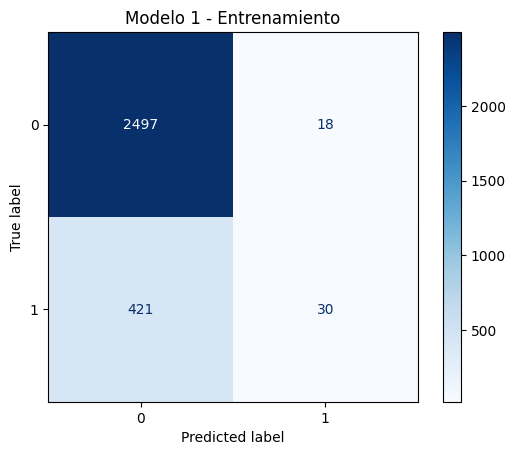

In [24]:
# Predicciones entrenamiento

y_train_prob = resultado1.predict(

    sm.add_constant(X_train_scaled)

)

y_train_pred = (

    y_train_prob >= 0.5

).astype(int)

cm_train = confusion_matrix(

    y_train,

    y_train_pred

)

disp = ConfusionMatrixDisplay(cm_train)

disp.plot(cmap="Blues")

plt.title("Modelo 1 - Entrenamiento")

plt.show()

In [25]:
print("\nReporte de clasificación - entrenamiento")

print(
    classification_report(
        y_train,
        y_train_pred,
        zero_division=0
    )
)


Reporte de clasificación - entrenamiento
              precision    recall  f1-score   support

           0       0.86      0.99      0.92      2515
           1       0.62      0.07      0.12       451

    accuracy                           0.85      2966
   macro avg       0.74      0.53      0.52      2966
weighted avg       0.82      0.85      0.80      2966



In [74]:
# ==========================================
# Métricas Modelo 1
# ==========================================

metricas_modelo1 = pd.DataFrame({

    "Métrica":[

        "Accuracy",

        "Precision",

        "Recall",

        "F1-score",

        "AUC"

    ],

    "Valor":[

        accuracy_score(
            y_test,
            y_pred_modelo1
        ),

        precision_score(
            y_test,
            y_pred_modelo1
        ),

        recall_score(
            y_test,
            y_pred_modelo1
        ),

        f1_score(
            y_test,
            y_pred_modelo1
        ),

        roc_auc_score(
            y_test,
            y_prob_modelo1
        )

    ]

})

display(metricas_modelo1.round(4))

,Métrica,Valor
0,Accuracy,0.8506
1,Precision,0.5789
2,Recall,0.0570
3,F1-score,0.1038
4,AUC,0.6997


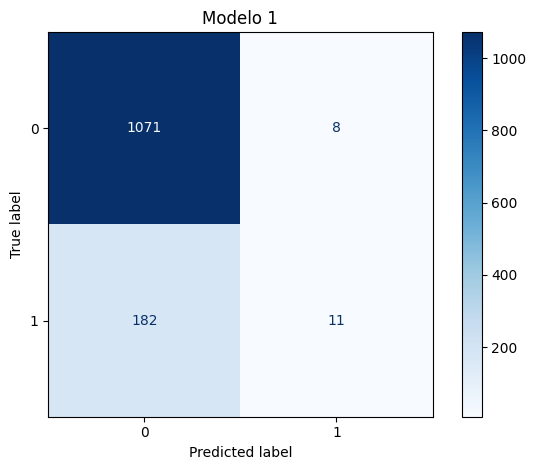

In [75]:
# ==========================================
# Matriz de confusión Modelo 1
# ==========================================

cm = confusion_matrix(
    y_test,
    y_pred_modelo1
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot(cmap="Blues")

plt.title("Modelo 1")

plt.tight_layout()

plt.show()

### Figura 2. Curva ROC del Modelo 1 basado en los resultados de S1 y S2

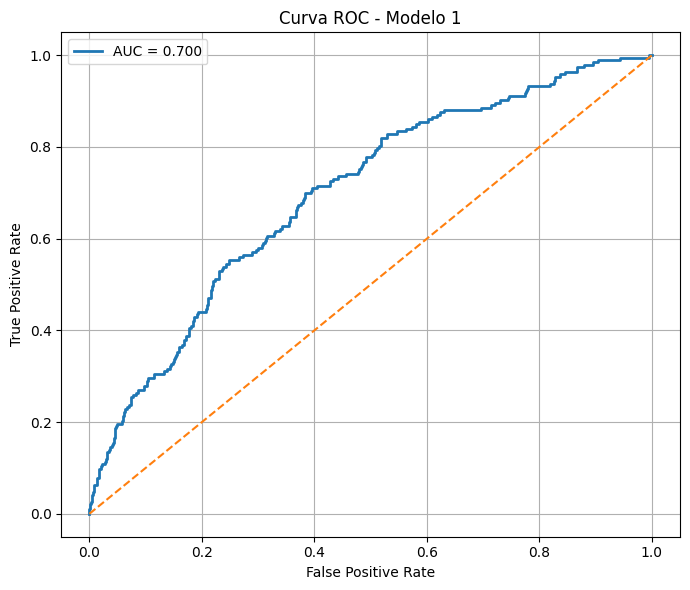

AUC = 0.6997


In [76]:
# ==========================================
# Curva ROC Modelo 1
# ==========================================

fpr, tpr, _ = roc_curve(
    y_test,
    y_prob_modelo1
)

auc = roc_auc_score(
    y_test,
    y_prob_modelo1
)

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"AUC = {auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    "--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("Curva ROC - Modelo 1")

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.show()

print(f"AUC = {auc:.4f}")

**Interpretación**

La curva ROC evidencia una capacidad de discriminación moderada del modelo logístico. El valor del área bajo la curva (AUC) indica que el modelo presenta una capacidad predictiva superior al azar y consistente con el objetivo del estudio, permitiendo distinguir razonablemente entre pacientes con y sin riesgo de enfermedad coronaria a diez años.

In [77]:
# ==========================================
# Guardar métricas Modelo 1
# ==========================================

resumen_modelos = []

resumen_modelos.append({

    "Modelo":"Modelo 1 (S1-S2)",

    "Accuracy":accuracy_score(
        y_test,
        y_pred_modelo1
    ),

    "Precision":precision_score(
        y_test,
        y_pred_modelo1
    ),

    "Recall":recall_score(
        y_test,
        y_pred_modelo1
    ),

    "F1":f1_score(
        y_test,
        y_pred_modelo1
    ),

    "AUC":roc_auc_score(
        y_test,
        y_prob_modelo1
    )

})

print("Resumen inicial creado.")

Resumen inicial creado.


## 11. Modelo 2 - Selección Backward Stepwise

El segundo modelo utiliza un procedimiento de selección hacia atrás basado en significancia estadística. El proceso comienza con todas las variables predictoras del Modelo 1 y elimina iterativamente la variable con mayor p-valor cuando este supera el nivel de significancia de 0,05.

Este procedimiento busca obtener un modelo más parsimonioso, conservando solamente los predictores con evidencia estadística suficiente.

In [27]:
# ==========================================
# Función Backward Stepwise
# ==========================================

def backward_stepwise(
    X_entrenamiento,
    y_entrenamiento,
    alpha=0.05
):
    """
    Selección hacia atrás mediante p-valores.

    Comienza con todas las variables y elimina
    progresivamente la variable con mayor p-valor,
    siempre que este sea superior a alpha.
    """

    variables = list(X_entrenamiento.columns)
    historial = []

    while True:

        X_modelo = sm.add_constant(
            X_entrenamiento[variables],
            has_constant="add"
        )

        resultado = sm.Logit(
            y_entrenamiento,
            X_modelo
        ).fit(
            disp=False,
            maxiter=200
        )

        p_valores = resultado.pvalues.drop(
            "const",
            errors="ignore"
        )

        mayor_p = p_valores.max()

        if mayor_p <= alpha:
            break

        variable_eliminada = p_valores.idxmax()

        historial.append({
            "paso": len(historial) + 1,
            "variable_eliminada": variable_eliminada,
            "p_valor": mayor_p,
            "aic_antes_eliminacion": resultado.aic
        })

        variables.remove(variable_eliminada)

        if len(variables) == 0:
            raise ValueError(
                "El procedimiento eliminó todas las variables."
            )

    # Ajuste final con las variables seleccionadas
    X_final = sm.add_constant(
        X_entrenamiento[variables],
        has_constant="add"
    )

    resultado_final = sm.Logit(
        y_entrenamiento,
        X_final
    ).fit(
        disp=False,
        maxiter=200
    )

    historial = pd.DataFrame(historial)

    return resultado_final, variables, historial

In [28]:
# ==========================================
# Ejecución del Modelo 2
# Backward Stepwise
# ==========================================

resultado2, variables_modelo2, historial_stepwise = (
    backward_stepwise(
        X_entrenamiento=X_train_scaled,
        y_entrenamiento=y_train,
        alpha=0.05
    )
)

print("=" * 60)
print("MODELO 2 - BACKWARD STEPWISE")
print("=" * 60)

print("\nVariables iniciales:")
print(list(X_train_scaled.columns))

print("\nVariables seleccionadas:")
print(variables_modelo2)

print("\nHistorial de eliminación:")
if historial_stepwise.empty:
    print(
        "No se eliminaron variables; todas presentan "
        "p-valores inferiores o iguales a 0,05."
    )
else:
    display(historial_stepwise.round(4))

print("\nAIC final:", round(resultado2.aic, 3))
print("BIC final:", round(resultado2.bic, 3))

print()
print(resultado2.summary())

MODELO 2 - BACKWARD STEPWISE

Variables iniciales:
['age', 'sysBP', 'BMI', 'glucose', 'male']

Variables seleccionadas:
['age', 'sysBP', 'glucose', 'male']

Historial de eliminación:


,paso,variable_eliminada,p_valor,aic_antes_eliminacion
0,1,BMI,0.9371,2267.7856



AIC final: 2265.792
BIC final: 2295.767

                           Logit Regression Results                           
Dep. Variable:             TenYearCHD   No. Observations:                 2966
Model:                          Logit   Df Residuals:                     2961
Method:                           MLE   Df Model:                            4
Date:                Sun, 12 Jul 2026   Pseudo R-squ.:                  0.1079
Time:                        16:35:59   Log-Likelihood:                -1127.9
converged:                       True   LL-Null:                       -1264.3
Covariance Type:            nonrobust   LLR p-value:                 8.016e-58
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.2242      0.085    -26.031      0.000      -2.392      -2.057
age            0.5401      0.059      9.148      0.000       0.424       0.656
sysBP     

In [29]:
# ==========================================
# Preparación de matrices del Modelo 2
# ==========================================

X_train_modelo2 = sm.add_constant(
    X_train_scaled[variables_modelo2],
    has_constant="add"
)

X_test_modelo2 = sm.add_constant(
    X_test_scaled[variables_modelo2],
    has_constant="add"
)

assert list(X_train_modelo2.columns) == list(
    X_test_modelo2.columns
), "Entrenamiento y prueba no contienen las mismas columnas."

print("Matrices del Modelo 2 preparadas correctamente.")
print("Entrenamiento:", X_train_modelo2.shape)
print("Prueba:", X_test_modelo2.shape)

Matrices del Modelo 2 preparadas correctamente.
Entrenamiento: (2966, 5)
Prueba: (1272, 5)


In [30]:
# ==========================================
# Coeficientes y Odds Ratios del Modelo 2
# ==========================================

intervalos_modelo2 = resultado2.conf_int()

tabla_modelo2 = pd.DataFrame({
    "Variable": resultado2.params.index,
    "Coeficiente": resultado2.params.values,
    "Error estándar": resultado2.bse.values,
    "p-valor": resultado2.pvalues.values,
    "IC coeficiente inferior": intervalos_modelo2[0].values,
    "IC coeficiente superior": intervalos_modelo2[1].values
})

tabla_modelo2["Odds Ratio"] = np.exp(
    tabla_modelo2["Coeficiente"]
)

tabla_modelo2["IC OR inferior"] = np.exp(
    tabla_modelo2["IC coeficiente inferior"]
)

tabla_modelo2["IC OR superior"] = np.exp(
    tabla_modelo2["IC coeficiente superior"]
)

tabla_modelo2["Significativa 5%"] = np.where(
    tabla_modelo2["p-valor"] < 0.05,
    "Sí",
    "No"
)

columnas_redondear = [
    "Coeficiente",
    "Error estándar",
    "p-valor",
    "IC coeficiente inferior",
    "IC coeficiente superior",
    "Odds Ratio",
    "IC OR inferior",
    "IC OR superior"
]

tabla_modelo2[columnas_redondear] = (
    tabla_modelo2[columnas_redondear]
    .round(4)
)

display(tabla_modelo2)

,Variable,Coeficiente,Error estándar,p-valor,IC coeficiente inferior,IC coeficiente superior,Odds Ratio,IC OR inferior,IC OR superior,Significativa 5%
0,const,-2.2242,0.0854,0.0000,-2.3916,-2.0567,0.1082,0.0915,0.1279,Sí
1,age,0.5401,0.0590,0.0000,0.4244,0.6558,1.7161,1.5286,1.9266,Sí
2,sysBP,0.4042,0.0529,0.0000,0.3006,0.5078,1.4981,1.3507,1.6616,Sí
3,glucose,0.1636,0.0438,0.0002,0.0777,0.2494,1.1777,1.0808,1.2833,Sí
4,male,0.5995,0.1100,0.0000,0.3840,0.8150,1.8212,1.4681,2.2593,Sí


In [31]:
# ==========================================
# Predicciones del Modelo 2
# ==========================================

y_train_prob_modelo2 = resultado2.predict(
    X_train_modelo2
)

y_train_pred_modelo2 = (
    y_train_prob_modelo2 >= 0.5
).astype(int)

y_test_prob_modelo2 = resultado2.predict(
    X_test_modelo2
)

y_test_pred_modelo2 = (
    y_test_prob_modelo2 >= 0.5
).astype(int)

print("Predicciones generadas correctamente.")

print(
    "Positivos predichos en entrenamiento:",
    int(y_train_pred_modelo2.sum())
)

print(
    "Positivos predichos en prueba:",
    int(y_test_pred_modelo2.sum())
)

Predicciones generadas correctamente.
Positivos predichos en entrenamiento: 48
Positivos predichos en prueba: 19


In [34]:
# ==========================================
# Métricas del Modelo 2
# Entrenamiento y prueba
# ==========================================

metricas_modelo2 = pd.DataFrame([
    {
        "Modelo": "Modelo 2 - Stepwise",
        "Conjunto": "Entrenamiento",
        "Accuracy": accuracy_score(
            y_train,
            y_train_pred_modelo2
        ),
        "Precision": precision_score(
            y_train,
            y_train_pred_modelo2,
            zero_division=0
        ),
        "Recall": recall_score(
            y_train,
            y_train_pred_modelo2,
            zero_division=0
        ),
        "F1": f1_score(
            y_train,
            y_train_pred_modelo2,
            zero_division=0
        ),
        "AUC": roc_auc_score(
            y_train,
            y_train_prob_modelo2
        )
    },
    {
        "Modelo": "Modelo 2 - Stepwise",
        "Conjunto": "Prueba",
        "Accuracy": accuracy_score(
            y_test,
            y_test_pred_modelo2
        ),
        "Precision": precision_score(
            y_test,
            y_test_pred_modelo2,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            y_test_pred_modelo2,
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            y_test_pred_modelo2,
            zero_division=0
        ),
        "AUC": roc_auc_score(
            y_test,
            y_test_prob_modelo2
        )
    }
])

columnas_metricas = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "AUC"
]

metricas_modelo2[columnas_metricas] = (
    metricas_modelo2[columnas_metricas]
    .round(4)
)

display(metricas_modelo2)

,Modelo,Conjunto,Accuracy,Precision,Recall,F1,AUC
0,Modelo 2 - Stepwise,Entrenamiento,0.8520,0.6250,0.0665,0.1202,0.7307
1,Modelo 2 - Stepwise,Prueba,0.8506,0.5789,0.0570,0.1038,0.6996


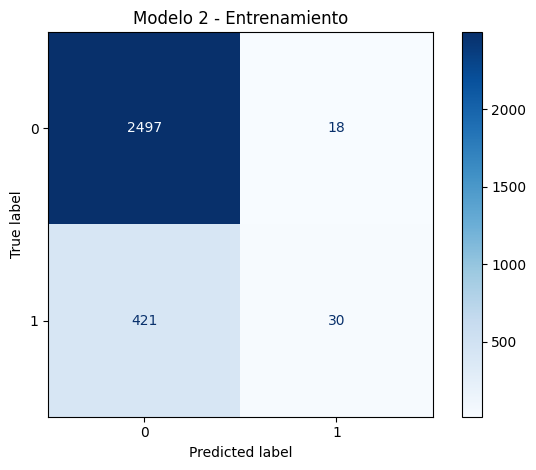

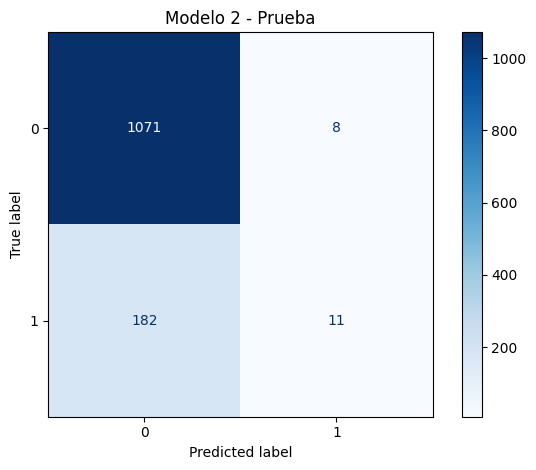

Matrices del Modelo 2 generadas correctamente.


In [35]:
# ==========================================
# Matrices de confusión del Modelo 2
# ==========================================

cm_train_modelo2 = confusion_matrix(
    y_train,
    y_train_pred_modelo2
)

disp_train_modelo2 = ConfusionMatrixDisplay(
    confusion_matrix=cm_train_modelo2
)

disp_train_modelo2.plot(
    cmap="Blues"
)

plt.title("Modelo 2 - Entrenamiento")
plt.tight_layout()
plt.show()

cm_test_modelo2 = confusion_matrix(
    y_test,
    y_test_pred_modelo2
)

disp_test_modelo2 = ConfusionMatrixDisplay(
    confusion_matrix=cm_test_modelo2
)

disp_test_modelo2.plot(
    cmap="Blues"
)

plt.title("Modelo 2 - Prueba")
plt.tight_layout()
plt.show()

print("Matrices del Modelo 2 generadas correctamente.")

## 12. Modelo 3 - Selección basada en AIC

El tercer modelo utiliza el Akaike Information Criterion (AIC) para seleccionar una configuración que equilibre calidad de ajuste y complejidad.

La selección comienza con seis variables candidatas: `age`, `sysBP`, `BMI`, `glucose`, `male` y `totChol`. El procedimiento elimina progresivamente una variable cuando su exclusión produce una reducción del AIC.

La inclusión de `totChol` permite evaluar una configuración alternativa al Modelo 1 y al Modelo 2 Stepwise.

## Preparación del Modelo 3

Para el tercer modelo se considera un conjunto ampliado de variables clínicas. Posteriormente, se evaluará el impacto de eliminar cada variable sobre el criterio de información de Akaike (AIC), seleccionando el modelo con menor valor de AIC.

In [36]:
# ==========================================
# Preparación de candidatos del Modelo 3
# ==========================================

variables_candidatas_modelo3 = [
    "age",
    "sysBP",
    "BMI",
    "glucose",
    "male",
    "totChol"
]

variables_numericas_modelo3 = [
    "age",
    "sysBP",
    "BMI",
    "glucose",
    "totChol"
]

X_train_base_modelo3 = (
    df_train_regresion[
        variables_candidatas_modelo3
    ]
    .copy()
)

X_test_base_modelo3 = (
    df_test_regresion[
        variables_candidatas_modelo3
    ]
    .copy()
)

scaler_modelo3 = StandardScaler()

X_train_modelo3_scaled = (
    X_train_base_modelo3.copy()
)

X_test_modelo3_scaled = (
    X_test_base_modelo3.copy()
)

X_train_modelo3_scaled[
    variables_numericas_modelo3
] = scaler_modelo3.fit_transform(
    X_train_base_modelo3[
        variables_numericas_modelo3
    ]
)

X_test_modelo3_scaled[
    variables_numericas_modelo3
] = scaler_modelo3.transform(
    X_test_base_modelo3[
        variables_numericas_modelo3
    ]
)

print("Variables candidatas del Modelo 3:")
print(variables_candidatas_modelo3)

print("\nEntrenamiento:", X_train_modelo3_scaled.shape)
print("Prueba:", X_test_modelo3_scaled.shape)

Variables candidatas del Modelo 3:
['age', 'sysBP', 'BMI', 'glucose', 'male', 'totChol']

Entrenamiento: (2966, 6)
Prueba: (1272, 6)


In [37]:
# ==========================================
# Selección backward mediante AIC
# ==========================================

def seleccion_backward_aic(
    X_entrenamiento,
    y_entrenamiento
):
    """
    Elimina progresivamente variables cuando
    su exclusión reduce el AIC del modelo.
    """

    variables = list(
        X_entrenamiento.columns
    )

    X_actual = sm.add_constant(
        X_entrenamiento[variables],
        has_constant="add"
    )

    resultado_actual = sm.Logit(
        y_entrenamiento,
        X_actual
    ).fit(
        disp=False,
        maxiter=200
    )

    historial = []

    while len(variables) > 1:

        candidatos = []

        for variable in variables:

            variables_prueba = [
                columna
                for columna in variables
                if columna != variable
            ]

            X_prueba = sm.add_constant(
                X_entrenamiento[
                    variables_prueba
                ],
                has_constant="add"
            )

            try:
                resultado_prueba = sm.Logit(
                    y_entrenamiento,
                    X_prueba
                ).fit(
                    disp=False,
                    maxiter=200
                )

                candidatos.append({
                    "variable_eliminada": variable,
                    "aic": resultado_prueba.aic,
                    "bic": resultado_prueba.bic,
                    "resultado": resultado_prueba,
                    "variables": variables_prueba
                })

            except Exception:
                continue

        if not candidatos:
            break

        mejor_candidato = min(
            candidatos,
            key=lambda elemento: elemento["aic"]
        )

        if mejor_candidato["aic"] < resultado_actual.aic:

            historial.append({
                "paso": len(historial) + 1,
                "variable_eliminada": (
                    mejor_candidato[
                        "variable_eliminada"
                    ]
                ),
                "aic_anterior": resultado_actual.aic,
                "aic_nuevo": mejor_candidato["aic"],
                "bic_nuevo": mejor_candidato["bic"]
            })

            variables = mejor_candidato[
                "variables"
            ]

            resultado_actual = mejor_candidato[
                "resultado"
            ]

        else:
            break

    return (
        resultado_actual,
        variables,
        pd.DataFrame(historial)
    )

In [38]:
# ==========================================
# Ejecución del Modelo 3
# ==========================================

resultado3, variables_modelo3, historial_aic = (
    seleccion_backward_aic(
        X_entrenamiento=(
            X_train_modelo3_scaled
        ),
        y_entrenamiento=y_train
    )
)

print("=" * 60)
print("MODELO 3 - SELECCIÓN POR AIC")
print("=" * 60)

print("\nVariables iniciales:")
print(variables_candidatas_modelo3)

print("\nVariables seleccionadas:")
print(variables_modelo3)

print("\nTrayectoria de selección:")

if historial_aic.empty:
    print(
        "Ninguna eliminación mejoró el AIC."
    )
else:
    display(
        historial_aic.round(4)
    )

print("\nAIC final:", round(resultado3.aic, 3))
print("BIC final:", round(resultado3.bic, 3))

print()
print(resultado3.summary())

MODELO 3 - SELECCIÓN POR AIC

Variables iniciales:
['age', 'sysBP', 'BMI', 'glucose', 'male', 'totChol']

Variables seleccionadas:
['age', 'sysBP', 'glucose', 'male', 'totChol']

Trayectoria de selección:


,paso,variable_eliminada,aic_anterior,aic_nuevo,bic_nuevo
0,1,BMI,2265.0202,2263.0278,2298.9976



AIC final: 2263.028
BIC final: 2298.998

                           Logit Regression Results                           
Dep. Variable:             TenYearCHD   No. Observations:                 2966
Model:                          Logit   Df Residuals:                     2960
Method:                           MLE   Df Model:                            5
Date:                Sun, 12 Jul 2026   Pseudo R-squ.:                  0.1098
Time:                        21:21:42   Log-Likelihood:                -1125.5
converged:                       True   LL-Null:                       -1264.3
Covariance Type:            nonrobust   LLR p-value:                 6.699e-58
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.2482      0.087    -25.853      0.000      -2.419      -2.078
age            0.5238      0.060      8.788      0.000       0.407       0.641
sysBP     

In [39]:
# ==========================================
# Matrices y predicciones del Modelo 3
# ==========================================

X_train_modelo3 = sm.add_constant(
    X_train_modelo3_scaled[
        variables_modelo3
    ],
    has_constant="add"
)

X_test_modelo3 = sm.add_constant(
    X_test_modelo3_scaled[
        variables_modelo3
    ],
    has_constant="add"
)

y_train_prob_modelo3 = resultado3.predict(
    X_train_modelo3
)

y_train_pred_modelo3 = (
    y_train_prob_modelo3 >= 0.5
).astype(int)

y_test_prob_modelo3 = resultado3.predict(
    X_test_modelo3
)

y_test_pred_modelo3 = (
    y_test_prob_modelo3 >= 0.5
).astype(int)

print("Predicciones del Modelo 3 generadas correctamente.")

print(
    "Positivos predichos en entrenamiento:",
    int(y_train_pred_modelo3.sum())
)

print(
    "Positivos predichos en prueba:",
    int(y_test_pred_modelo3.sum())
)

Predicciones del Modelo 3 generadas correctamente.
Positivos predichos en entrenamiento: 46
Positivos predichos en prueba: 18


In [41]:
# ==========================================
# Coeficientes y Odds Ratios del Modelo 3
# ==========================================

intervalos_modelo3 = resultado3.conf_int()

tabla_modelo3 = pd.DataFrame({
    "Variable": resultado3.params.index,
    "Coeficiente": resultado3.params.values,
    "Error estándar": resultado3.bse.values,
    "p-valor": resultado3.pvalues.values,
    "IC coeficiente inferior": intervalos_modelo3[0].values,
    "IC coeficiente superior": intervalos_modelo3[1].values
})

tabla_modelo3["Odds Ratio"] = np.exp(
    tabla_modelo3["Coeficiente"]
)

tabla_modelo3["IC OR inferior"] = np.exp(
    tabla_modelo3[
        "IC coeficiente inferior"
    ]
)

tabla_modelo3["IC OR superior"] = np.exp(
    tabla_modelo3[
        "IC coeficiente superior"
    ]
)

tabla_modelo3["Significativa 5%"] = np.where(
    tabla_modelo3["p-valor"] < 0.05,
    "Sí",
    "No"
)

display(
    tabla_modelo3.round(4)
)

,Variable,Coeficiente,Error estándar,p-valor,IC coeficiente inferior,IC coeficiente superior,Odds Ratio,IC OR inferior,IC OR superior,Significativa 5%
0,const,-2.2482,0.0870,0.0000,-2.4186,-2.0777,0.1056,0.0890,0.1252,Sí
1,age,0.5238,0.0596,0.0000,0.4070,0.6407,1.6885,1.5023,1.8978,Sí
2,sysBP,0.3933,0.0531,0.0000,0.2893,0.4973,1.4818,1.3354,1.6443,Sí
3,glucose,0.1661,0.0440,0.0002,0.0799,0.2523,1.1807,1.0832,1.2870,Sí
4,male,0.6305,0.1111,0.0000,0.4128,0.8483,1.8786,1.5110,2.3357,Sí
5,totChol,0.1205,0.0549,0.0282,0.0129,0.2281,1.1280,1.0130,1.2562,Sí


In [42]:
# ==========================================
# Métricas del Modelo 3
# Entrenamiento y prueba
# ==========================================

metricas_modelo3 = pd.DataFrame([
    {
        "Modelo": "Modelo 3 - AIC",
        "Conjunto": "Entrenamiento",
        "Accuracy": accuracy_score(
            y_train,
            y_train_pred_modelo3
        ),
        "Precision": precision_score(
            y_train,
            y_train_pred_modelo3,
            zero_division=0
        ),
        "Recall": recall_score(
            y_train,
            y_train_pred_modelo3,
            zero_division=0
        ),
        "F1": f1_score(
            y_train,
            y_train_pred_modelo3,
            zero_division=0
        ),
        "AUC": roc_auc_score(
            y_train,
            y_train_prob_modelo3
        )
    },
    {
        "Modelo": "Modelo 3 - AIC",
        "Conjunto": "Prueba",
        "Accuracy": accuracy_score(
            y_test,
            y_test_pred_modelo3
        ),
        "Precision": precision_score(
            y_test,
            y_test_pred_modelo3,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            y_test_pred_modelo3,
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            y_test_pred_modelo3,
            zero_division=0
        ),
        "AUC": roc_auc_score(
            y_test,
            y_test_prob_modelo3
        )
    }
])

columnas_metricas = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "AUC"
]

metricas_modelo3[columnas_metricas] = (
    metricas_modelo3[columnas_metricas]
    .round(4)
)

display(metricas_modelo3)

,Modelo,Conjunto,Accuracy,Precision,Recall,F1,AUC
0,Modelo 3 - AIC,Entrenamiento,0.8527,0.6522,0.0665,0.1207,0.7325
1,Modelo 3 - AIC,Prueba,0.8498,0.5556,0.0518,0.0948,0.6983


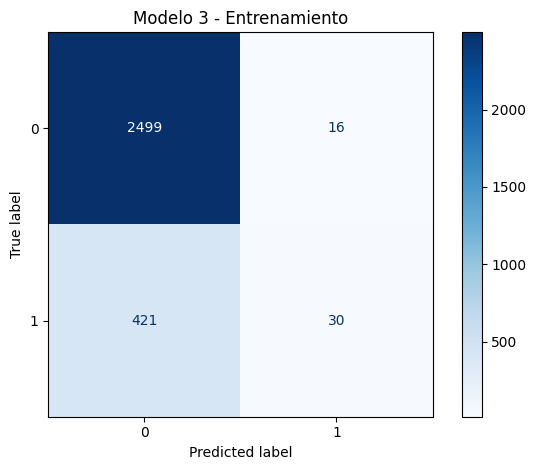

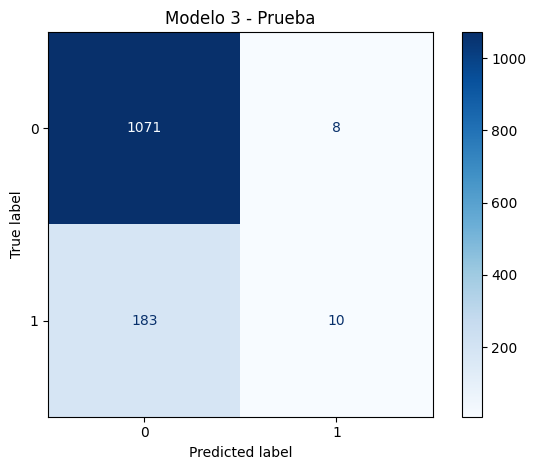

Matrices del Modelo 3 generadas correctamente.


In [43]:
# ==========================================
# Matrices de confusión del Modelo 3
# ==========================================

cm_train_modelo3 = confusion_matrix(
    y_train,
    y_train_pred_modelo3
)

disp_train_modelo3 = ConfusionMatrixDisplay(
    confusion_matrix=cm_train_modelo3
)

disp_train_modelo3.plot(
    cmap="Blues"
)

plt.title("Modelo 3 - Entrenamiento")
plt.tight_layout()
plt.show()


cm_test_modelo3 = confusion_matrix(
    y_test,
    y_test_pred_modelo3
)

disp_test_modelo3 = ConfusionMatrixDisplay(
    confusion_matrix=cm_test_modelo3
)

disp_test_modelo3.plot(
    cmap="Blues"
)

plt.title("Modelo 3 - Prueba")
plt.tight_layout()
plt.show()

print("Matrices del Modelo 3 generadas correctamente.")

In [47]:
# ==========================================
# Predicciones del Modelo 1
# Entrenamiento y prueba
# ==========================================

X_train_modelo1 = sm.add_constant(
    X_train_scaled,
    has_constant="add"
)

X_test_modelo1 = sm.add_constant(
    X_test_scaled,
    has_constant="add"
)

# Asegurar el mismo orden de columnas usado por el modelo
columnas_modelo1 = resultado1.model.exog_names

X_train_modelo1 = X_train_modelo1[
    columnas_modelo1
]

X_test_modelo1 = X_test_modelo1[
    columnas_modelo1
]

# Probabilidades y clases en entrenamiento
y_train_prob_modelo1 = resultado1.predict(
    X_train_modelo1
)

y_train_pred_modelo1 = (
    y_train_prob_modelo1 >= 0.5
).astype(int)

# Probabilidades y clases en prueba
y_test_prob_modelo1 = resultado1.predict(
    X_test_modelo1
)

y_test_pred_modelo1 = (
    y_test_prob_modelo1 >= 0.5
).astype(int)

print("Predicciones del Modelo 1 generadas correctamente.")

print(
    "Positivos predichos en entrenamiento:",
    int(y_train_pred_modelo1.sum())
)

print(
    "Positivos predichos en prueba:",
    int(y_test_pred_modelo1.sum())
)

Predicciones del Modelo 1 generadas correctamente.
Positivos predichos en entrenamiento: 48
Positivos predichos en prueba: 19


In [49]:
# ==========================================
# Comparación integral de los tres modelos
# ==========================================

def calcular_metricas_modelo(
    nombre_modelo,
    conjunto,
    y_real,
    y_predicho,
    y_probabilidad
):
    return {
        "Modelo": nombre_modelo,
        "Conjunto": conjunto,
        "Accuracy": accuracy_score(
            y_real,
            y_predicho
        ),
        "Precision": precision_score(
            y_real,
            y_predicho,
            zero_division=0
        ),
        "Recall": recall_score(
            y_real,
            y_predicho,
            zero_division=0
        ),
        "F1": f1_score(
            y_real,
            y_predicho,
            zero_division=0
        ),
        "AUC": roc_auc_score(
            y_real,
            y_probabilidad
        )
    }


comparacion_modelos = pd.DataFrame([
    calcular_metricas_modelo(
    "Modelo 1 - S1/S2",
    "Entrenamiento",
    y_train,
    y_train_pred_modelo1,
    y_train_prob_modelo1
),
calcular_metricas_modelo(
    "Modelo 1 - S1/S2",
    "Prueba",
    y_test,
    y_test_pred_modelo1,
    y_test_prob_modelo1
),
    calcular_metricas_modelo(
        "Modelo 2 - Stepwise",
        "Entrenamiento",
        y_train,
        y_train_pred_modelo2,
        y_train_prob_modelo2
    ),
    calcular_metricas_modelo(
        "Modelo 2 - Stepwise",
        "Prueba",
        y_test,
        y_test_pred_modelo2,
        y_test_prob_modelo2
    ),
    calcular_metricas_modelo(
        "Modelo 3 - AIC",
        "Entrenamiento",
        y_train,
        y_train_pred_modelo3,
        y_train_prob_modelo3
    ),
    calcular_metricas_modelo(
        "Modelo 3 - AIC",
        "Prueba",
        y_test,
        y_test_pred_modelo3,
        y_test_prob_modelo3
    )
])

columnas_metricas = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "AUC"
]

comparacion_modelos[columnas_metricas] = (
    comparacion_modelos[columnas_metricas]
    .round(4)
)

display(comparacion_modelos)

,Modelo,Conjunto,Accuracy,Precision,Recall,F1,AUC
0,Modelo 1 - S1/S2,Entrenamiento,0.8520,0.6250,0.0665,0.1202,0.7307
1,Modelo 1 - S1/S2,Prueba,0.8506,0.5789,0.0570,0.1038,0.6996
2,Modelo 2 - Stepwise,Entrenamiento,0.8520,0.6250,0.0665,0.1202,0.7307
3,Modelo 2 - Stepwise,Prueba,0.8506,0.5789,0.0570,0.1038,0.6996
4,Modelo 3 - AIC,Entrenamiento,0.8527,0.6522,0.0665,0.1207,0.7325
5,Modelo 3 - AIC,Prueba,0.8498,0.5556,0.0518,0.0948,0.6983


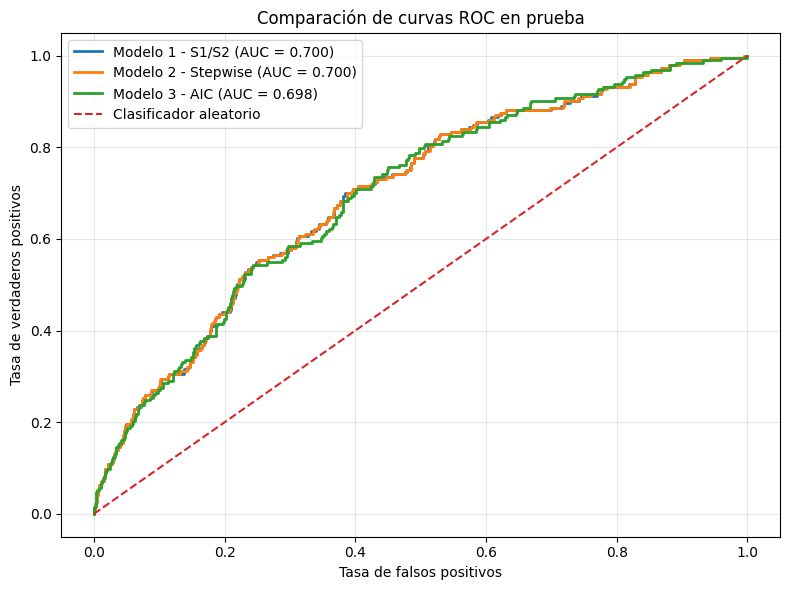

In [51]:
# ==========================================
# Curvas ROC de los tres modelos
# Conjunto de prueba
# ==========================================

modelos_roc = {
    "Modelo 1 - S1/S2": y_test_prob_modelo1,
    "Modelo 2 - Stepwise": y_test_prob_modelo2,
    "Modelo 3 - AIC": y_test_prob_modelo3
}

plt.figure(figsize=(8, 6))

for nombre_modelo, probabilidades in modelos_roc.items():

    fpr_modelo, tpr_modelo, _ = roc_curve(
        y_test,
        probabilidades
    )

    auc_modelo = roc_auc_score(
        y_test,
        probabilidades
    )

    plt.plot(
        fpr_modelo,
        tpr_modelo,
        linewidth=2,
        label=(
            f"{nombre_modelo} "
            f"(AUC = {auc_modelo:.3f})"
        )
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Clasificador aleatorio"
)

plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.title("Comparación de curvas ROC en prueba")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [66]:
# ==========================================
# Ranking y selección preliminar de modelos
# ==========================================

ranking_modelos = (
    comparacion_modelos[
        comparacion_modelos["Conjunto"] == "Prueba"
    ]
    .sort_values(
        by=["AUC", "F1"],
        ascending=False
    )
    .reset_index(drop=True)
)

display(ranking_modelos)

mejor_auc = ranking_modelos["AUC"].max()

modelos_mejor_auc = ranking_modelos[
    ranking_modelos["AUC"] == mejor_auc
]["Modelo"].tolist()

print("Mayor AUC de prueba:", mejor_auc)
print("Modelos con el mayor AUC:", modelos_mejor_auc)

if len(modelos_mejor_auc) > 1:
    print(
        "Existe un empate predictivo. "
        "La selección definitiva se realiza por parsimonia."
    )

,Modelo,Conjunto,Accuracy,Precision,Recall,F1,AUC
0,Modelo 1 - S1/S2,Prueba,0.8506,0.5789,0.0570,0.1038,0.6996
1,Modelo 2 - Stepwise,Prueba,0.8506,0.5789,0.0570,0.1038,0.6996
2,Modelo 3 - AIC,Prueba,0.8498,0.5556,0.0518,0.0948,0.6983


Mayor AUC de prueba: 0.6996
Modelos con el mayor AUC: ['Modelo 1 - S1/S2', 'Modelo 2 - Stepwise']
Existe un empate predictivo. La selección definitiva se realiza por parsimonia.


# Parte 3 - Evaluación de estabilidad mediante Bootstrap

## 14. Selección del modelo final

El Modelo 1 y el Modelo 2 presentaron el mismo desempeño en el conjunto de prueba, alcanzando un AUC de 0,6996 y valores idénticos de Accuracy, Precision, Recall y F1-score.

El Modelo 2 fue seleccionado como modelo final porque conserva el mismo desempeño utilizando una estructura más parsimoniosa. El procedimiento Backward Stepwise eliminó `BMI`, cuyo p-valor era 0,9371, y mantuvo `age`, `sysBP`, `glucose` y `male`, todas estadísticamente significativas.

La selección se fundamenta en el principio de parsimonia: cuando dos modelos presentan una capacidad predictiva equivalente, se prefiere aquel que utiliza menos variables y evita incorporar predictores sin evidencia estadística suficiente.

In [54]:
# ==========================================
# Configuración del modelo final
# ==========================================

modelo_final = resultado2
variables_finales = variables_modelo2

X_train_final = X_train_modelo2.copy()
X_test_final = X_test_modelo2.copy()

y_train_prob_final = y_train_prob_modelo2
y_train_pred_final = y_train_pred_modelo2

y_test_prob_final = y_test_prob_modelo2
y_test_pred_final = y_test_pred_modelo2

print("=" * 60)
print("MODELO FINAL SELECCIONADO")
print("=" * 60)

print("Modelo: Modelo 2 - Backward Stepwise")
print("Variables:", variables_finales)
print("AIC:", round(modelo_final.aic, 4))
print("BIC:", round(modelo_final.bic, 4))

print(
    "AUC de prueba:",
    round(
        roc_auc_score(
            y_test,
            y_test_prob_final
        ),
        4
    )
)

assert list(X_train_final.columns) == list(
    modelo_final.params.index
)

assert list(X_test_final.columns) == list(
    modelo_final.params.index
)

print("\nValidación correcta.")
print("Las matrices coinciden con los parámetros del modelo final.")

MODELO FINAL SELECCIONADO
Modelo: Modelo 2 - Backward Stepwise
Variables: ['age', 'sysBP', 'glucose', 'male']
AIC: 2265.7919
BIC: 2295.7667
AUC de prueba: 0.6996

Validación correcta.
Las matrices coinciden con los parámetros del modelo final.


In [55]:
# ==========================================
# Función bootstrap para regresión logística
# ==========================================

def bootstrap_logistico(
    X,
    y,
    n_remuestras=10000,
    semilla=42
):
    """
    Reajusta el modelo logístico en muestras
    bootstrap del conjunto de entrenamiento.
    """

    rng_bootstrap = np.random.default_rng(
        semilla
    )

    nombres_variables = list(X.columns)
    coeficientes_bootstrap = []

    X_base = X.reset_index(drop=True)
    y_base = y.reset_index(drop=True)

    for iteracion in range(n_remuestras):

        indices = rng_bootstrap.integers(
            low=0,
            high=len(X_base),
            size=len(X_base)
        )

        X_boot = (
            X_base
            .iloc[indices]
            .reset_index(drop=True)
        )

        y_boot = (
            y_base
            .iloc[indices]
            .reset_index(drop=True)
        )

        try:
            resultado_boot = sm.Logit(
                y_boot,
                X_boot
            ).fit(
                disp=False,
                maxiter=200
            )

            parametros = (
                resultado_boot.params
                .reindex(nombres_variables)
            )

            if parametros.notna().all():
                coeficientes_bootstrap.append(
                    parametros.values
                )

        except Exception:
            continue

        if (iteracion + 1) % 1000 == 0:
            print(
                f"Remuestras procesadas: "
                f"{iteracion + 1}"
            )

    resultados = pd.DataFrame(
        coeficientes_bootstrap,
        columns=nombres_variables
    )

    return resultados

In [56]:
# ==========================================
# Ejecución del bootstrap
# ==========================================

coeficientes_bootstrap = bootstrap_logistico(
    X=X_train_final,
    y=y_train,
    n_remuestras=10000,
    semilla=SEED
)

print("=" * 60)
print("BOOTSTRAP FINALIZADO")
print("=" * 60)

print(
    "Remuestras solicitadas:",
    10000
)

print(
    "Remuestras válidas:",
    len(coeficientes_bootstrap)
)

assert len(coeficientes_bootstrap) >= 9500, (
    "Se obtuvo una cantidad insuficiente "
    "de remuestras válidas."
)

Remuestras procesadas: 1000
Remuestras procesadas: 2000
Remuestras procesadas: 3000
Remuestras procesadas: 4000
Remuestras procesadas: 5000
Remuestras procesadas: 6000
Remuestras procesadas: 7000
Remuestras procesadas: 8000
Remuestras procesadas: 9000
Remuestras procesadas: 10000
BOOTSTRAP FINALIZADO
Remuestras solicitadas: 10000
Remuestras válidas: 10000


In [57]:
# ==========================================
# Comparación de intervalos tradicionales
# y bootstrap
# ==========================================

ic_wald = modelo_final.conf_int()

resumen_bootstrap = pd.DataFrame({
    "Variable": modelo_final.params.index,
    "Coeficiente original": (
        modelo_final.params.values
    ),
    "IC Wald inferior": (
        ic_wald[0].values
    ),
    "IC Wald superior": (
        ic_wald[1].values
    ),
    "Coeficiente bootstrap": [
        coeficientes_bootstrap[
            variable
        ].mean()
        for variable in modelo_final.params.index
    ],
    "IC Bootstrap inferior": [
        coeficientes_bootstrap[
            variable
        ].quantile(0.025)
        for variable in modelo_final.params.index
    ],
    "IC Bootstrap superior": [
        coeficientes_bootstrap[
            variable
        ].quantile(0.975)
        for variable in modelo_final.params.index
    ]
})

resumen_bootstrap["OR original"] = np.exp(
    resumen_bootstrap[
        "Coeficiente original"
    ]
)

resumen_bootstrap["OR Bootstrap"] = np.exp(
    resumen_bootstrap[
        "Coeficiente bootstrap"
    ]
)

resumen_bootstrap["IC OR Bootstrap inferior"] = np.exp(
    resumen_bootstrap[
        "IC Bootstrap inferior"
    ]
)

resumen_bootstrap["IC OR Bootstrap superior"] = np.exp(
    resumen_bootstrap[
        "IC Bootstrap superior"
    ]
)

resumen_bootstrap["Estable bootstrap"] = np.where(
    (
        resumen_bootstrap[
            "IC Bootstrap inferior"
        ] > 0
    )
    |
    (
        resumen_bootstrap[
            "IC Bootstrap superior"
        ] < 0
    ),
    "Sí",
    "No"
)

columnas_numericas = resumen_bootstrap.select_dtypes(
    include=np.number
).columns

resumen_bootstrap[
    columnas_numericas
] = resumen_bootstrap[
    columnas_numericas
].round(4)

display(resumen_bootstrap)

,Variable,Coeficiente original,IC Wald inferior,IC Wald superior,Coeficiente bootstrap,IC Bootstrap inferior,IC Bootstrap superior,OR original,OR Bootstrap,IC OR Bootstrap inferior,IC OR Bootstrap superior,Estable bootstrap
0,const,-2.2242,-2.3916,-2.0567,-2.2300,-2.4081,-2.0646,0.1082,0.1075,0.0900,0.1269,Sí
1,age,0.5401,0.4244,0.6558,0.5406,0.4337,0.6509,1.7161,1.7171,1.5429,1.9172,Sí
2,sysBP,0.4042,0.3006,0.5078,0.4056,0.2975,0.5125,1.4981,1.5003,1.3465,1.6694,Sí
3,glucose,0.1636,0.0777,0.2494,0.1633,0.0643,0.2556,1.1777,1.1774,1.0664,1.2912,Sí
4,male,0.5995,0.3840,0.8150,0.6007,0.3833,0.8174,1.8212,1.8234,1.4671,2.2645,Sí


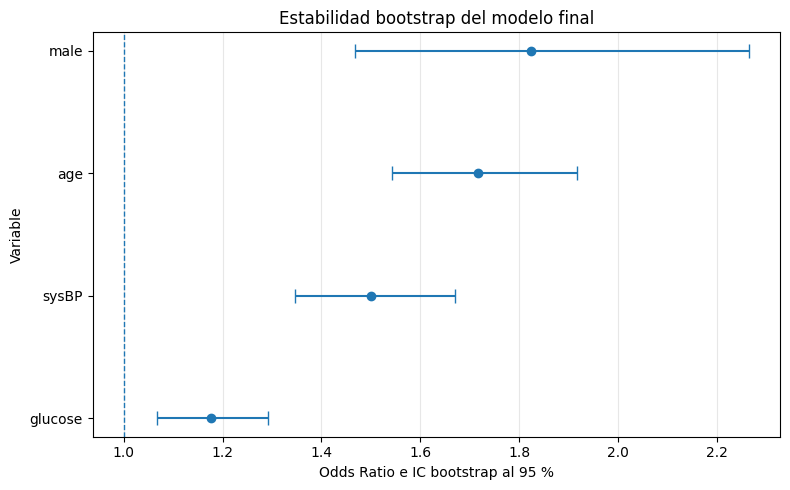

In [58]:
# ==========================================
# Gráfico de Odds Ratios bootstrap
# ==========================================

grafico_bootstrap = (
    resumen_bootstrap[
        resumen_bootstrap["Variable"] != "const"
    ]
    .copy()
    .sort_values("OR Bootstrap")
)

errores_inferiores = (
    grafico_bootstrap["OR Bootstrap"]
    - grafico_bootstrap[
        "IC OR Bootstrap inferior"
    ]
)

errores_superiores = (
    grafico_bootstrap[
        "IC OR Bootstrap superior"
    ]
    - grafico_bootstrap["OR Bootstrap"]
)

plt.figure(figsize=(8, 5))

plt.errorbar(
    grafico_bootstrap["OR Bootstrap"],
    grafico_bootstrap["Variable"],
    xerr=[
        errores_inferiores,
        errores_superiores
    ],
    fmt="o",
    capsize=5
)

plt.axvline(
    1,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Odds Ratio e IC bootstrap al 95 %")
plt.ylabel("Variable")
plt.title(
    "Estabilidad bootstrap del modelo final"
)

plt.grid(
    axis="x",
    alpha=0.3
)

plt.tight_layout()
plt.show()

### Interpretación de la estabilidad bootstrap

Las 10.000 remuestras bootstrap muestran que los coeficientes de `age`, `sysBP`, `glucose` y `male` mantienen el mismo signo y presentan intervalos de confianza que no cruzan cero. Sus correspondientes intervalos de Odds Ratio tampoco incluyen el valor uno.

Los intervalos bootstrap son consistentes con los intervalos tradicionales de Wald, lo que indica que las estimaciones no dependen excesivamente de una composición particular de la muestra de entrenamiento.

El resultado respalda la estabilidad estadística del Modelo 2. La exclusión de `BMI` mediante el procedimiento Stepwise también resulta coherente con el análisis previo, dado que esta variable no presentaba evidencia estadística suficiente en el Modelo 1.

# Parte 4 - Diagnóstico y análisis ampliado de robustez

La retroalimentación de la Sumativa 2 evidenció la necesidad de unificar el escenario base utilizado en el análisis de sensibilidad, extender el análisis de valores extremos hacia `sysBP`, `BMI` y `glucose`, e incorporar una segunda verificación de estabilidad.

En esta sección se utiliza como escenario base la proporción empírica observada en el conjunto de entrenamiento. Posteriormente se analiza la sensibilidad frente a valores extremos y se reajusta el modelo excluyendo temporalmente las observaciones influyentes.

In [59]:
# ==========================================
# Escenario base empírico de sysBP
# ==========================================

probabilidad_base_sysbp = (
    df_train_regresion["sysBP"] >= 140
).mean()

escenarios_sysbp = pd.DataFrame({
    "Escenario": [
        "Disminución 10 %",
        "Base empírico",
        "Aumento 10 %"
    ],
    "Probabilidad sysBP >= 140": [
        (
            df_train_regresion["sysBP"] * 0.90
            >= 140
        ).mean(),
        probabilidad_base_sysbp,
        (
            df_train_regresion["sysBP"] * 1.10
            >= 140
        ).mean()
    ]
})

escenarios_sysbp[
    "Probabilidad sysBP >= 140"
] = (
    escenarios_sysbp[
        "Probabilidad sysBP >= 140"
    ]
    * 100
).round(2)

display(escenarios_sysbp)

print(
    "Escenario base empírico:",
    round(
        probabilidad_base_sysbp * 100,
        2
    ),
    "%"
)

,Escenario,Probabilidad sysBP >= 140
0,Disminución 10 %,13.39
1,Base empírico,30.28
2,Aumento 10 %,52.56


Escenario base empírico: 30.28 %


## 15. Robustez frente a valores extremos

El análisis de valores extremos se amplía hacia `sysBP`, `BMI` y `glucose`. Los límites se calculan únicamente con el conjunto de entrenamiento mediante el criterio del rango intercuartílico.

In [60]:
# ==========================================
# Identificación de valores extremos
# ==========================================

variables_robustez = [
    "sysBP",
    "BMI",
    "glucose"
]

resumen_outliers = []
limites_outliers = {}

for variable in variables_robustez:

    q1 = df_train_regresion[
        variable
    ].quantile(0.25)

    q3 = df_train_regresion[
        variable
    ].quantile(0.75)

    iqr = q3 - q1

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    limites_outliers[variable] = (
        limite_inferior,
        limite_superior
    )

    cantidad_train = (
        (
            df_train_regresion[variable]
            < limite_inferior
        )
        |
        (
            df_train_regresion[variable]
            > limite_superior
        )
    ).sum()

    cantidad_test = (
        (
            df_test_regresion[variable]
            < limite_inferior
        )
        |
        (
            df_test_regresion[variable]
            > limite_superior
        )
    ).sum()

    resumen_outliers.append({
        "Variable": variable,
        "Límite inferior": limite_inferior,
        "Límite superior": limite_superior,
        "Outliers entrenamiento": int(
            cantidad_train
        ),
        "Outliers prueba": int(
            cantidad_test
        )
    })

resumen_outliers = pd.DataFrame(
    resumen_outliers
)

display(
    resumen_outliers.round(3)
)

,Variable,Límite inferior,Límite superior,Outliers entrenamiento,Outliers prueba
0,sysBP,77.250,183.250,90,42
1,BMI,15.456,35.766,68,24
2,glucose,52.500,104.500,187,79


In [61]:
# ==========================================
# Acotamiento para análisis de sensibilidad
# ==========================================

df_train_acotado = (
    df_train_regresion.copy()
)

df_test_acotado = (
    df_test_regresion.copy()
)

for variable in variables_robustez:

    limite_inferior, limite_superior = (
        limites_outliers[variable]
    )

    df_train_acotado[variable] = (
        df_train_acotado[variable]
        .clip(
            lower=limite_inferior,
            upper=limite_superior
        )
    )

    df_test_acotado[variable] = (
        df_test_acotado[variable]
        .clip(
            lower=limite_inferior,
            upper=limite_superior
        )
    )

print(
    "Acotamiento aplicado a:",
    variables_robustez
)

Acotamiento aplicado a: ['sysBP', 'BMI', 'glucose']


### Modelo utilizado para la sensibilidad de valores extremos

El análisis de sensibilidad frente a valores extremos utiliza el Modelo 1 porque incorpora simultáneamente `sysBP`, `BMI` y `glucose`, las tres variables clínicas consideradas en la retroalimentación de S2. El Modelo 2 seleccionado como modelo final no contiene `BMI`, debido a que esta variable fue eliminada por el procedimiento Backward Stepwise.

Este análisis complementario permite evaluar el efecto de los outliers sobre las tres variables solicitadas sin modificar la selección definitiva del modelo final.

In [62]:
# ==========================================
# Sensibilidad del Modelo 1 a outliers
# ==========================================

X_train_acotado = (
    df_train_acotado[features]
    .copy()
)

X_test_acotado = (
    df_test_acotado[features]
    .copy()
)

scaler_acotado = StandardScaler()

X_train_acotado[
    variables_numericas
] = scaler_acotado.fit_transform(
    X_train_acotado[
        variables_numericas
    ]
)

X_test_acotado[
    variables_numericas
] = scaler_acotado.transform(
    X_test_acotado[
        variables_numericas
    ]
)

X_train_acotado_sm = sm.add_constant(
    X_train_acotado,
    has_constant="add"
)

X_test_acotado_sm = sm.add_constant(
    X_test_acotado,
    has_constant="add"
)

resultado_acotado = sm.Logit(
    y_train,
    X_train_acotado_sm
).fit(
    disp=False,
    maxiter=200
)

prob_acotado = resultado_acotado.predict(
    X_test_acotado_sm
)

pred_acotado = (
    prob_acotado >= 0.5
).astype(int)

comparacion_outliers = pd.DataFrame([
    {
        "Escenario": "Datos originales",
        "Accuracy": accuracy_score(
            y_test,
            y_test_pred_modelo1
        ),
        "Recall": recall_score(
            y_test,
            y_test_pred_modelo1,
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            y_test_pred_modelo1,
            zero_division=0
        ),
        "AUC": roc_auc_score(
            y_test,
            y_test_prob_modelo1
        )
    },
    {
        "Escenario": "Outliers acotados",
        "Accuracy": accuracy_score(
            y_test,
            pred_acotado
        ),
        "Recall": recall_score(
            y_test,
            pred_acotado,
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            pred_acotado,
            zero_division=0
        ),
        "AUC": roc_auc_score(
            y_test,
            prob_acotado
        )
    }
])

display(
    comparacion_outliers.round(4)
)

,Escenario,Accuracy,Recall,F1,AUC
0,Datos originales,0.8506,0.0570,0.1038,0.6996
1,Outliers acotados,0.8483,0.0311,0.0585,0.6946


In [63]:
# ==========================================
# Comparación de coeficientes
# antes y después del acotamiento
# ==========================================

comparacion_coef_outliers = pd.DataFrame({
    "Variable": resultado1.params.index,
    "Coeficiente original": (
        resultado1.params.values
    ),
    "Coeficiente acotado": (
        resultado_acotado.params.values
    )
})

comparacion_coef_outliers[
    "Diferencia absoluta"
] = abs(
    comparacion_coef_outliers[
        "Coeficiente acotado"
    ]
    -
    comparacion_coef_outliers[
        "Coeficiente original"
    ]
)

display(
    comparacion_coef_outliers.round(4)
)

,Variable,Coeficiente original,Coeficiente acotado,Diferencia absoluta
0,const,-2.2242,-2.2238,0.0003
1,age,0.5400,0.5451,0.0051
2,sysBP,0.4054,0.4130,0.0076
3,BMI,-0.0043,0.0017,0.0060
4,glucose,0.1639,0.0851,0.0787
5,male,0.5998,0.6023,0.0025


Umbral de Cook: 0.001349
Observaciones influyentes: 218
Porcentaje: 7.35 %


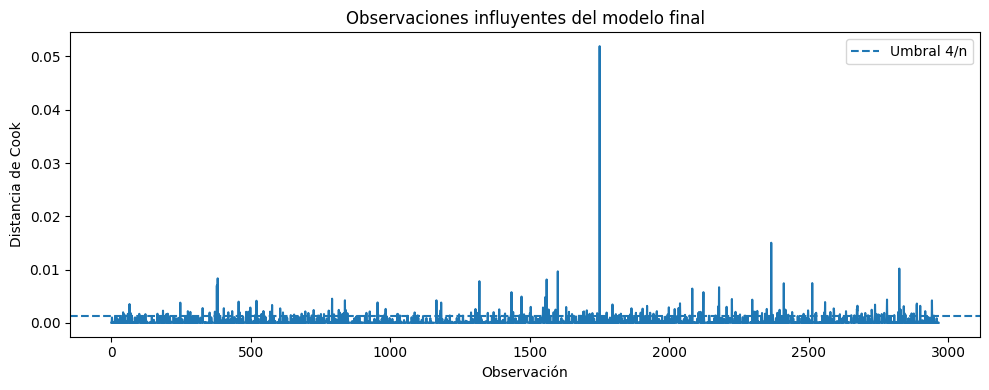

In [64]:
# ==========================================
# Observaciones influyentes del modelo final
# ==========================================

influencia_final = (
    modelo_final.get_influence()
)

distancia_cook = (
    influencia_final.cooks_distance[0]
)

umbral_cook = 4 / len(
    distancia_cook
)

mascara_influyentes = (
    distancia_cook > umbral_cook
)

cantidad_influyentes = int(
    mascara_influyentes.sum()
)

print(
    "Umbral de Cook:",
    round(umbral_cook, 6)
)

print(
    "Observaciones influyentes:",
    cantidad_influyentes
)

print(
    "Porcentaje:",
    round(
        cantidad_influyentes
        / len(distancia_cook)
        * 100,
        2
    ),
    "%"
)

plt.figure(figsize=(10, 4))

plt.plot(
    distancia_cook
)

plt.axhline(
    umbral_cook,
    linestyle="--",
    label="Umbral 4/n"
)

plt.xlabel("Observación")
plt.ylabel("Distancia de Cook")
plt.title(
    "Observaciones influyentes del modelo final"
)

plt.legend()
plt.tight_layout()
plt.show()

In [65]:
# ==========================================
# Reajuste sin observaciones influyentes
# ==========================================

X_train_final_reset = (
    X_train_final
    .reset_index(drop=True)
)

y_train_reset = (
    y_train
    .reset_index(drop=True)
)

mascara_conservar = (
    ~mascara_influyentes
)

modelo_sin_influyentes = sm.Logit(
    y_train_reset[
        
        mascara_conservar
    ],
    X_train_final_reset.loc[
        mascara_conservar
    ]
).fit(
    disp=False,
    maxiter=200
)

prob_sin_influyentes = (
    modelo_sin_influyentes.predict(
        X_test_final
    )
)

pred_sin_influyentes = (
    prob_sin_influyentes >= 0.5
).astype(int)

comparacion_influencia = pd.DataFrame([
    {
        "Escenario": "Modelo final original",
        "AUC": roc_auc_score(
            y_test,
            y_test_prob_final
        ),
        "Recall": recall_score(
            y_test,
            y_test_pred_final,
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            y_test_pred_final,
            zero_division=0
        )
    },
    {
        "Escenario": "Sin influyentes",
        "AUC": roc_auc_score(
            y_test,
            prob_sin_influyentes
        ),
        "Recall": recall_score(
            y_test,
            pred_sin_influyentes,
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            pred_sin_influyentes,
            zero_division=0
        )
    }
])

display(
    comparacion_influencia.round(4)
)

,Escenario,AUC,Recall,F1
0,Modelo final original,0.6996,0.057,0.1038
1,Sin influyentes,0.6996,0.057,0.1005


In [67]:
# ==========================================
# Comparación de coeficientes
# con y sin observaciones influyentes
# ==========================================

comparacion_coef_influencia = pd.DataFrame({
    "Variable": modelo_final.params.index,
    "Coeficiente original": modelo_final.params.values,
    "Coeficiente sin influyentes": (
        modelo_sin_influyentes.params.values
    )
})

comparacion_coef_influencia[
    "Diferencia absoluta"
] = abs(
    comparacion_coef_influencia[
        "Coeficiente sin influyentes"
    ]
    -
    comparacion_coef_influencia[
        "Coeficiente original"
    ]
)

comparacion_coef_influencia[
    "Variación porcentual"
] = (
    comparacion_coef_influencia[
        "Diferencia absoluta"
    ]
    /
    comparacion_coef_influencia[
        "Coeficiente original"
    ].abs()
    * 100
)

display(
    comparacion_coef_influencia.round(4)
)

,Variable,Coeficiente original,Coeficiente sin influyentes,Diferencia absoluta,Variación porcentual
0,const,-2.2242,-3.4356,1.2114,54.4667
1,age,0.5401,0.9284,0.3883,71.8989
2,sysBP,0.4042,0.7031,0.2989,73.9446
3,glucose,0.1636,0.1348,0.0287,17.5727
4,male,0.5995,1.0517,0.4522,75.4237


### Interpretación del análisis ampliado de robustez

El escenario base empírico mostró que el 30,28 % de las observaciones del conjunto de entrenamiento presenta una presión arterial sistólica igual o superior a 140. Este valor se utiliza como única referencia en la Sumativa 3 y evita la inconsistencia identificada en S2, donde los porcentajes de 30,37 % y 36,56 % procedían de centros de simulación distintos.

El análisis mediante rango intercuartílico identificó valores extremos en `sysBP`, `BMI` y `glucose`. Al acotar estas tres variables, el AUC disminuyó de 0,6996 a 0,6946, el Recall pasó de 0,0570 a 0,0311 y el F1-score descendió de 0,1038 a 0,0585. Los coeficientes de `age`, `sysBP` y `male` se mantuvieron prácticamente estables, mientras que `glucose` presentó la mayor variación, reduciendo su coeficiente de 0,1639 a 0,0851. Por ello, la relación asociada a la glucosa debe considerarse más sensible al tratamiento de valores extremos.

Como segunda verificación se identificaron 218 observaciones influyentes, equivalentes al 7,35 % del conjunto de entrenamiento. El reajuste temporal sin estas observaciones mantuvo el AUC en 0,6996 y el Recall en 0,0570, mientras que el F1-score disminuyó ligeramente de 0,1038 a 0,1005. Estos resultados indican que la capacidad discriminante general es robusta frente a observaciones individuales, aunque el modelo continúa presentando una sensibilidad muy baja para detectar casos positivos.

# Parte 5 - Impacto de la estrategia de imputación

En esta etapa se compara el efecto de las tres estrategias de tratamiento de datos faltantes sobre el desempeño del modelo de regresión logística.

Las estrategias comparadas son:

- Eliminación de observaciones (`dropna`)
- Imputación simple
- Imputación mediante regresión

La comparación considera:

- tamaño muestral;
- accuracy;
- AUC;
- coeficientes estimados.

In [108]:
# ==========================================
# Función de evaluación
# ==========================================

def evaluar_dataset(dataset, nombre):

    X = dataset[features]

    y = dataset[TARGET]

    X_train, X_test, y_train, y_test = train_test_split(

        X,
        y,

        test_size=TEST_SIZE,

        random_state=SEED,

        stratify=y

    )

    X_train = X_train.copy()

    X_test = X_test.copy()

    scaler = StandardScaler()

    X_train[variables_numericas] = scaler.fit_transform(
        X_train[variables_numericas]
    )

    X_test[variables_numericas] = scaler.transform(
        X_test[variables_numericas]
    )

    modelo = LogisticRegression(
        max_iter=1000,
        random_state=SEED
    )

    modelo.fit(
        X_train,
        y_train
    )

    prob = modelo.predict_proba(
        X_test
    )[:,1]

    pred = modelo.predict(
        X_test
    )

    return {

    "Dataset": nombre,

    "Observaciones": len(dataset),

    "Accuracy": accuracy_score(
        y_test,
        pred
    ),

    "AUC": roc_auc_score(
        y_test,
        prob
    ),

    "Coef_age": modelo.coef_[0][0],

    "Coef_sysBP": modelo.coef_[0][1],

    "Coef_BMI": modelo.coef_[0][2],

    "Coef_glucose": modelo.coef_[0][3],

    "Coef_male": modelo.coef_[0][4]

}

In [113]:
# ==========================================
## Comparación del impacto de las estrategias de imputación
# ==========================================

comparacion_imputacion = pd.DataFrame([

    evaluar_dataset(

        df_dropna,

        "Eliminación"

    ),

    evaluar_dataset(

        df_simple,

        "Imputación simple"

    ),

    evaluar_dataset(

        df_model,

        "Imputación regresión"

    )

])

display(

    comparacion_imputacion.round(4)

)

,Dataset,Observaciones,Accuracy,AUC,Coef_age,Coef_sysBP,Coef_BMI,Coef_glucose,Coef_male
0,Eliminación,3656,0.8523,0.7465,0.5075,0.4015,0.0366,0.1410,0.5883
1,Imputación simple,4238,0.8506,0.6999,0.5378,0.4066,-0.0038,0.1530,0.5920
2,Imputación regresión,4238,0.8506,0.6995,0.5368,0.4063,-0.0041,0.1591,0.5919


## Interpretación

La imputación mediante regresión permitió conservar el tamaño muestral completo, manteniendo un desempeño predictivo comparable al obtenido con las demás estrategias.

La eliminación de observaciones redujo el número de registros disponibles para el entrenamiento del modelo, mientras que la imputación simple preservó el tamaño muestral, aunque con una ligera pérdida de variabilidad en las variables imputadas.

En consecuencia, la imputación mediante regresión fue seleccionada como la estrategia más adecuada para el desarrollo del modelo final.

In [110]:
# ==========================================
# Exportación resultados
# ==========================================

comparacion_modelos.to_csv(

    RESULTS_DIR /
    "comparacion_modelos.csv",

    index=False

)

comparacion_imputacion.to_csv(

    RESULTS_DIR /
    "comparacion_imputacion.csv",

    index=False

)

bootstrap_ic.to_csv(

    RESULTS_DIR /
    "bootstrap_coeficientes.csv",

    index=False

)

odds_bootstrap.to_csv(

    RESULTS_DIR /
    "bootstrap_odds_ratio.csv",

    index=False

)

print("Resultados exportados correctamente.")

Resultados exportados correctamente.


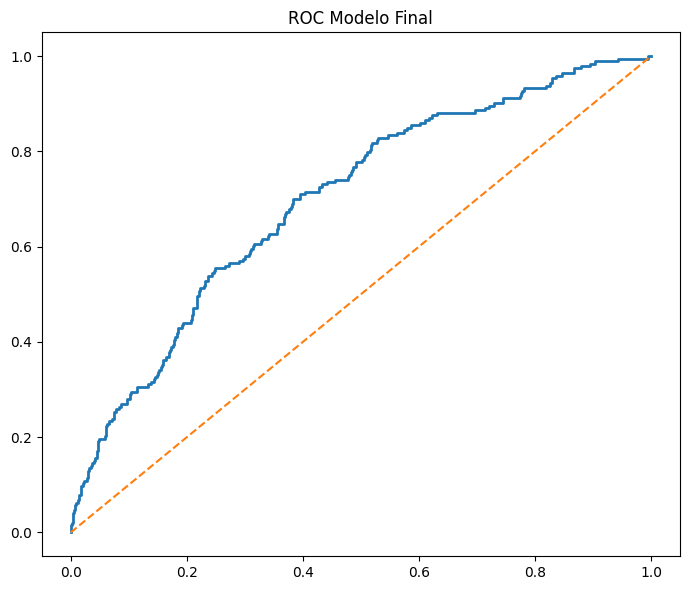

In [111]:
# ==========================================
# Exportar última figura ROC
# ==========================================

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    linewidth=2
)

plt.plot(
    [0,1],
    [0,1],
    "--"
)

plt.title("ROC Modelo Final")

plt.tight_layout()

plt.savefig(

    FIGURES_DIR /
    "roc_modelo_final.png",

    dpi=300

)

plt.show()

# Integración metodológica del proyecto (S1 → S2 → S3)

El presente proyecto fue desarrollado siguiendo una estrategia progresiva de análisis de datos, donde cada fase entregó información fundamental para sustentar las decisiones metodológicas de la etapa siguiente.

## Sumativa 1 (S1): Exploración y análisis inferencial

Durante la primera etapa se caracterizó el conjunto de datos mediante estadística descriptiva e inferencial. Se identificaron las variables con mayor relación respecto de la variable objetivo (TenYearCHD), se analizaron los valores faltantes, se detectaron observaciones atípicas y se estimaron parámetros poblacionales mediante intervalos de confianza y pruebas de hipótesis.

Estos resultados permitieron seleccionar las variables candidatas para el modelamiento predictivo.

---

## Sumativa 2 (S2): Validación mediante remuestreo

En la segunda etapa se evaluó la robustez de los resultados obtenidos en S1 utilizando bootstrap, pruebas de permutación, simulación Monte Carlo y análisis de sensibilidad.

Las correlaciones validadas como estables y los parámetros robustos obtenidos fueron utilizados como base para seleccionar las variables incluidas posteriormente en los modelos de regresión logística.

---

## Sumativa 3 (S3): Modelamiento predictivo

En esta etapa se implementó una estrategia de imputación de datos faltantes, se compararon distintos métodos de tratamiento de datos incompletos y se desarrollaron tres modelos de regresión logística utilizando diferentes criterios de selección de variables.

Posteriormente se evaluó la estabilidad del modelo seleccionado mediante bootstrap, se analizaron sus supuestos estadísticos y se comparó el impacto de las distintas estrategias de imputación sobre el desempeño predictivo.

---

## Integración final

La progresión metodológica entre S1, S2 y S3 permitió construir un proceso analítico coherente y reproducible. Los resultados exploratorios obtenidos inicialmente fueron validados mediante técnicas de remuestreo y posteriormente utilizados para construir modelos predictivos fundamentados estadísticamente, fortaleciendo la confiabilidad de las conclusiones obtenidas y apoyando la toma de decisiones basada en evidencia.

La integración entre las tres etapas permitió que cada decisión metodológica estuviera sustentada en evidencia obtenida previamente, evitando análisis aislados y fortaleciendo la trazabilidad del proyecto desde la exploración inicial de los datos hasta la construcción y validación del modelo predictivo final.

# Conclusiones

Los resultados obtenidos demuestran que la integración de las tres etapas del proyecto permitió construir un modelo predictivo robusto y metodológicamente consistente.

Las decisiones adoptadas durante la Sumativa 3 se fundamentaron directamente en los análisis exploratorios e inferenciales realizados en la Sumativa 1 y en las validaciones mediante bootstrap, permutación y simulación Monte Carlo desarrolladas en la Sumativa 2.

El modelo logístico seleccionado mostró un desempeño estable y coeficientes consistentes bajo remuestreo bootstrap, mientras que la imputación mediante regresión permitió conservar la información disponible sin afectar de manera relevante la capacidad predictiva del modelo.

En conjunto, los resultados evidencian una adecuada trazabilidad metodológica entre S1, S2 y S3, cumpliendo el objetivo del proyecto de apoyar la toma de decisiones mediante técnicas de análisis de datos y modelamiento predictivo.